This notebook serves as a demo to test creatively generated mixtures of 2 and 6 images, based on the creativity metric proposed by [Quantitative Measures of Task-Oriented Creativity in Popular Generative Vision Models](https://arxiv.org/pdf/2505.04497). I generated this primarily using Claude Code with some additional tweaks to parameters etc.

In [ ]:
from typing import Union

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms

from sklearn.neighbors import NearestNeighbors

# ─────────────────────────────────────────────────────────────
# 1. Data
# ─────────────────────────────────────────────────────────────

def get_mnist_26(batch_size: int = 128, train: bool = True):
    """Return a DataLoader containing only MNIST digits 2 and 6."""
    dataset = torchvision.datasets.MNIST(
        root="./data", train=train, download=True,
        transform=transforms.ToTensor()
    )
    indices = [i for i, y in enumerate(dataset.targets.tolist()) if y in (2, 6)]
    loader = DataLoader(Subset(dataset, indices), batch_size=batch_size, shuffle=train)
    return loader


def cache_flat_images(loader) -> np.ndarray:
    """Flatten all images in a loader into an (N, 784) numpy array."""
    parts = []
    for x, _ in loader:
        parts.append(x.view(x.size(0), -1).numpy())
    return np.concatenate(parts, axis=0)

In [2]:
# ─────────────────────────────────────────────────────────────
# 2. VAE
# ─────────────────────────────────────────────────────────────

class VAE(nn.Module):
    def __init__(self, latent_dim: int = 32):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder_body = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, 784),        nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28)),
        )

    def encode(self, x):
        h = self.encoder_body(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

    def sample(self, n: int, device) -> torch.Tensor:
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decoder(z)


def vae_loss(x_recon, x, mu, logvar, beta: float = 1.0):
    recon = F.binary_cross_entropy(x_recon, x, reduction="sum") / x.size(0)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl

In [3]:
# ─────────────────────────────────────────────────────────────
# 3. Classifier  (2 → class 0,  6 → class 1)
# ─────────────────────────────────────────────────────────────

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.net(x)

    def probs(self, x):
        return F.softmax(self.forward(x), dim=1)

In [4]:
# ─────────────────────────────────────────────────────────────
# 4. Training helpers
# ─────────────────────────────────────────────────────────────

def train_vae(vae, loader, epochs: int = 20, lr: float = 1e-3,
              device: Union[str, torch.device] = "cpu", beta: float = 1.0):
    opt = optim.Adam(vae.parameters(), lr=lr)
    vae.train()
    for epoch in range(epochs):
        total = 0.0
        for x, _ in loader:
            x = x.to(device)
            x_recon, mu, logvar = vae(x)
            loss = vae_loss(x_recon, x, mu, logvar, beta=beta)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f"  [VAE] epoch {epoch+1:>3}/{epochs}  loss={total/len(loader):.4f}")


def train_classifier(clf, loader, epochs: int = 10, lr: float = 1e-3, device: Union[str, torch.device] = "cpu"):
    opt = optim.Adam(clf.parameters(), lr=lr)
    clf.train()
    for epoch in range(epochs):
        total, correct, n = 0.0, 0, 0
        for x, y in loader:
            x = x.to(device)
            y = (y == 6).long().to(device)   # 2→0, 6→1
            logits = clf(x)
            loss = F.cross_entropy(logits, y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total   += loss.item()
            correct += (logits.argmax(1) == y).sum().item()
            n       += y.size(0)
        if (epoch + 1) % 5 == 0:
            print(f"  [CLF] epoch {epoch+1:>3}/{epochs}  "
                  f"loss={total/len(loader):.4f}  acc={correct/n:.4f}")


This next code snippet is the implementation of the creativity metrics used in the paper. Essentially, they use a formula for creativity as a combination of a novelty and usefulness score. The usefulness just tracks the success at generating an image that the classifier labels as equally likely to be a 2 and a 6 (i.e. the min of both probabilities). The novelty score tries to detect the distance from the training set to the generated image using a nearest neighbors classifier. It only uses one neighbor because it wants to track closeness to any training example. As `nn_dist` gets farther from the training examples, this term approaches 1. This metric then evenly weights both usefulness and novelty for an overall creativity score

In [5]:
# ─────────────────────────────────────────────────────────────
# 5. Creativity scoring  (Ramaswamy et al.)
# ─────────────────────────────────────────────────────────────

def score_creativity(images: torch.Tensor, clf: Classifier,
                     train_flat: np.ndarray, device: Union[str, torch.device] = "cpu",
                     alpha: float = 0.5):
    """
    Compute per-image creativity scores.

    Creativity(x) = Novelty(x)^alpha * Usefulness(x)^(1-alpha)

    Usefulness  = min(P(2|x), P(6|x))
                  Peaks when the classifier is equally confident the image
                  is a 2 AND a 6 — the ideal creative combination.

    Novelty     = nn_dist / (1 + nn_dist)
                  Saturates toward 1 as the image moves away from all
                  training examples; 0 if the image is a copy of one.
    """
    clf.eval()
    with torch.no_grad():
        probs = clf.probs(images.to(device)).cpu().numpy()   # (N, 2)

    usefulness = np.minimum(probs[:, 0], probs[:, 1])        # (N,)

    flat = images.view(images.size(0), -1).cpu().numpy()     # (N, 784)
    nbrs = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(train_flat)
    nn_dist = nbrs.kneighbors(flat)[0][:, 0]                 # (N,)
    novelty = nn_dist / (1.0 + nn_dist)

    creativity = (novelty ** alpha) * (usefulness ** (1.0 - alpha))
    return creativity, novelty, usefulness

## Extended Creativity Metric

The simple metric above conflates two separate ideas under "novelty" (pixel distance) and collapses task-relevance into a single min-probability term. The extended metric decomposes creativity into three orthogonal factors:

| Term | What it measures | Implementation |
|---|---|---|
| **Structural novelty** | Topological difference from any training image | Wasserstein-1 distance between the sample's H1 persistence diagram (sublevel-set filtration on pixel values) and the nearest diagram in a training subset, normalised as $d/(1+d)$ |
| **Realness / interpretability** | Does the image look like a plausible handwritten mark? | $1 / (1 + \text{MSE}(x, \hat{x}))$ where $\hat{x}$ is reconstructed by an autoencoder trained on **all 10** MNIST classes |
| **Class ambiguity** | Is the classifier maximally uncertain between 2 and 6? | Jensen-Shannon divergence between the classifier's output $p$ and the uniform distribution $u = [0.5, 0.5]$, using log base 2 so JS $\in [0, 1]$; maximised when $p = u$ |

Combined as a weighted geometric mean:

$$\text{ExtCreativity}(x) = \text{StructuralNovelty}(x)^{w_1} \cdot \text{Realness}(x)^{w_2} \cdot \text{Ambiguity}(x)^{w_3}$$

The realness and ambiguity terms are differentiable through the AE and classifier, so two of the three objectives can be directly optimised by gradient ascent. Topological novelty is evaluated post-hoc only.

In [6]:
# ─────────────────────────────────────────────────────────────
# 5b. Extended creativity components
# ─────────────────────────────────────────────────────────────

# ── 5b-i. General autoencoder (trained on all MNIST) ─────────

class GeneralAE(nn.Module):
    """Simple AE trained on all 10 MNIST classes.  Low reconstruction
    error means the image looks like a plausible handwritten mark."""
    def __init__(self, latent_dim: int = 64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28)),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_general_ae(ae: GeneralAE, epochs: int = 10, lr: float = 1e-3,
                     device: Union[str, torch.device] = "cpu"):
    """Train the general AE on all 10 MNIST classes."""
    full_dataset = torchvision.datasets.MNIST(
        root="./data", train=True, download=True,
        transform=transforms.ToTensor()
    )
    loader = DataLoader(full_dataset, batch_size=256, shuffle=True)
    opt = optim.Adam(ae.parameters(), lr=lr)
    ae.train()
    for epoch in range(epochs):
        total = 0.0
        for x, _ in loader:
            x = x.to(device)
            loss = F.mse_loss(ae(x), x)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f"  [AE] epoch {epoch+1:>3}/{epochs}  loss={total/len(loader):.6f}")


# ── 5b-ii. Persistent homology ────────────────────────────────
# Uses gudhi (cubical complex, H1) + persim (Wasserstein distance).

try:
    import gudhi
    from persim import wasserstein as _wasserstein
    TOPO_AVAILABLE = True
except ImportError:
    TOPO_AVAILABLE = False
    print("gudhi / persim not found — structural novelty will be set to 0.")
    print("Install with:  pip install gudhi persim")


def _persistence_h1(img_np: np.ndarray) -> np.ndarray:
    """H1 persistence diagram via cubical sublevel-set filtration.
    Infinite deaths are dropped; returns [[0,0]] if no finite H1 features."""
    cc = gudhi.CubicalComplex(
        dimensions=[28, 28],
        top_dimensional_cells=img_np.flatten().tolist()
    )
    cc.compute_persistence()
    dgm = cc.persistence_intervals_in_dimension(1)
    if len(dgm) == 0:
        return np.array([[0.0, 0.0]])
    finite = dgm[np.isfinite(dgm[:, 1])]
    return finite if len(finite) > 0 else np.array([[0.0, 0.0]])


def compute_train_diagrams(train_flat: np.ndarray,
                            n_samples: int = 150,
                            seed: int = 0) -> list:
    """Compute H1 diagrams for a random subset of training images."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(train_flat), size=min(n_samples, len(train_flat)),
                     replace=False)
    diagrams = []
    for i, j in enumerate(idx):
        diagrams.append(_persistence_h1(train_flat[j].reshape(28, 28)))
        if (i + 1) % 50 == 0:
            print(f"  [TOPO] {i+1}/{len(idx)} training diagrams computed")
    return diagrams

def _wd(d1, d2) -> float:
    r = _wasserstein(d1, d2, matching=False)
    return float(r[0]) if isinstance(r, tuple) else float(r)

def topological_novelty(images: torch.Tensor, train_diagrams: list) -> np.ndarray:
    """Min Wasserstein-1 distance to any training H1 diagram, normalised
    as d / (1 + d).  Requires TOPO_AVAILABLE."""
    imgs_np = images.squeeze().numpy()   # (N, 28, 28)
    scores = []
    for img in imgs_np:
        dgm = _persistence_h1(img)
        min_d = min(_wd(dgm, td) for td in train_diagrams)
        scores.append(min_d / (1.0 + min_d))
    return np.array(scores, dtype=np.float32)


# ── 5b-iii. Jensen-Shannon ambiguity ─────────────────────────


def js_ambiguity(probs: np.ndarray) -> np.ndarray:
    """
    JS divergence (log base 2) between each row of `probs` and the
    uniform distribution u = [0.5, 0.5].  Result is in [0, 1];
    equals 1 when p = [0.5, 0.5] (maximum uncertainty).
    """
    u = np.full_like(probs, 0.5)
    m = 0.5 * (probs + u)
    eps = 1e-10
    kl_pm = np.sum(probs * np.log2((probs + eps) / (m + eps)), axis=1)
    kl_um = np.sum(u     * np.log2((u     + eps) / (m + eps)), axis=1)
    return np.clip(0.5 * kl_pm + 0.5 * kl_um, 0.0, 1.0)


def js_ambiguity_torch(probs: torch.Tensor) -> torch.Tensor:
    """Differentiable version of js_ambiguity for gradient-based optimisation."""
    u = torch.full_like(probs, 0.5)
    m = 0.5 * (probs + u)
    eps = 1e-10
    kl_pm = (probs * torch.log2((probs + eps) / (m + eps))).sum(dim=1)
    kl_um = (u     * torch.log2((u     + eps) / (m + eps))).sum(dim=1)
    return torch.clamp(0.5 * kl_pm + 0.5 * kl_um, 0.0, 1.0)


# ── 5b-iv. Extended creativity score ─────────────────────────

def score_creativity_extended(images: torch.Tensor,
                               clf: Classifier,
                               ae: GeneralAE,
                               train_flat: np.ndarray,
                               train_diagrams: list,
                               device: Union[str, torch.device] = "cpu",
                               weights: tuple = (1/3, 1/3, 1/3)):
    """
    ExtCreativity = StructuralNovelty^w1 · Realness^w2 · Ambiguity^w3

    StructuralNovelty — min Wasserstein-1 distance in H1 diagram space,
                        normalised by d/(1+d).  0 if gudhi unavailable.
    Realness          — 1 / (1 + MSE(x, AE(x))); near 1 for digit-like images.
    Ambiguity         — JS divergence from classifier output to uniform [0.5, 0.5];
                        equals 1 when the classifier is maximally uncertain.
    """
    w1, w2, w3 = weights
    ae.eval()
    clf.eval()

    with torch.no_grad():
        imgs_dev = images.to(device)
        recon    = ae(imgs_dev)
        mse      = F.mse_loss(recon, imgs_dev, reduction="none") \
                     .mean(dim=[1, 2, 3]).cpu().numpy()
        probs    = clf.probs(imgs_dev).cpu().numpy()

    realness  = 1.0 / (1.0 + mse)
    ambiguity = js_ambiguity(probs)

    if TOPO_AVAILABLE and len(train_diagrams) > 0:
        struct_novelty = topological_novelty(images.cpu(), train_diagrams)
    else:
        struct_novelty = np.zeros(len(images), dtype=np.float32)

    ext_creativity = (struct_novelty ** w1) * (realness ** w2) * (ambiguity ** w3)
    return ext_creativity, struct_novelty, realness, ambiguity

This next code snippet just generates the images. It also generates a latent space interpolation baseline as an example to compare to. To generate the new images, it does a search over the latent space with the goal of maximizing the creativity metric

In [7]:
# ─────────────────────────────────────────────────────────────
# 6a. Latent interpolation baseline
# ─────────────────────────────────────────────────────────────

def generate_interpolated(vae: VAE, loader, n_samples: int = 32,
                           t: float = 0.5, device: Union[str, torch.device] = "cpu") -> torch.Tensor:
    """
    Generate images by linearly interpolating between the encoded means
    of paired digit-2 and digit-6 examples.

        z_interp = (1 - t) * mu_2  +  t * mu_6

    t=0.5 is the midpoint — equal mixture of both identities.
    Using the posterior mean (no noise) keeps interpolations smooth and
    on the VAE manifold, but they are anchored to real training pairs,
    so novelty is inherently limited compared to free latent optimisation.
    """
    vae.eval()
    mus_2, mus_6 = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            mu, _ = vae.encode(x)
            mask_2 = (y == 2)
            mask_6 = (y == 6)
            if mask_2.any():
                mus_2.append(mu[mask_2])
            if mask_6.any():
                mus_6.append(mu[mask_6])
            n2 = sum(m.size(0) for m in mus_2)
            n6 = sum(m.size(0) for m in mus_6)
            if n2 >= n_samples and n6 >= n_samples:
                break

    mus_2 = torch.cat(mus_2)[:n_samples]   # (N, latent_dim)
    mus_6 = torch.cat(mus_6)[:n_samples]   # (N, latent_dim)

    z_interp = (1.0 - t) * mus_2 + t * mus_6
    with torch.no_grad():
        return vae.decoder(z_interp).cpu()


# ─────────────────────────────────────────────────────────────
# 6b. Creative generation  (latent optimisation)
# ─────────────────────────────────────────────────────────────

def generate_creative(vae: VAE, clf: Classifier, train_flat: np.ndarray,
                      n_samples: int = 32, n_steps: int = 300,
                      lr: float = 0.05, device: Union[str, torch.device] = "cpu",
                      alpha: float = 0.5) -> torch.Tensor:
    """
    Search for latent codes z* that maximise the creativity objective.

    Unlike latent interpolation (which mixes known encodings), this
    directly optimises in the full latent space, allowing the decoder
    to reach configurations never seen during training — satisfying the
    'novelty' requirement — while the classifier loss drives the images
    toward ambiguous 2/6 territory — satisfying 'usefulness'.

    The gradient flows through the VAE decoder and the classifier,
    so both objectives shape the latent code simultaneously.
    """
    vae.eval()
    clf.eval()

    # Initialise latent codes as learnable parameters
    z = torch.randn(n_samples, vae.latent_dim, device=device, requires_grad=True)
    opt = optim.Adam([z], lr=lr)

    # Pre-load training set on device for differentiable nearest-neighbour approx
    train_t = torch.tensor(train_flat, dtype=torch.float32, device=device)

    for step in range(n_steps):
        opt.zero_grad()

        images = vae.decoder(z)                               # (N, 1, 28, 28)
        probs  = clf.probs(images)                            # (N, 2)

        # Usefulness: both class probabilities should be high simultaneously
        usefulness = torch.min(probs[:, 0], probs[:, 1])     # (N,)

        # Novelty: differentiable soft minimum distance to training set
        flat   = images.view(n_samples, -1)                   # (N, 784)
        dists  = torch.cdist(flat, train_t)                   # (N, M)
        nn_d   = dists.min(dim=1).values                      # (N,)
        novelty = nn_d / (1.0 + nn_d)

        # Creativity objective (negate for minimisation)
        creativity = (novelty ** alpha) * (usefulness ** (1.0 - alpha))
        loss = -creativity.mean()

        loss.backward()
        opt.step()

        if (step + 1) % 75 == 0:
            print(f"  [OPT] step {step+1:>4}/{n_steps}  "
                  f"creativity={creativity.mean().item():.4f}  "
                  f"novelty={novelty.mean().item():.4f}  "
                  f"usefulness={usefulness.mean().item():.4f}")

    with torch.no_grad():
        return vae.decoder(z).cpu()

In [8]:
# ─────────────────────────────────────────────────────────────
# 6c. Creative generation — extended objective
# ─────────────────────────────────────────────────────────────

def generate_creative_extended(vae: VAE, clf: Classifier, ae: GeneralAE,
                                train_flat: np.ndarray,
                                n_samples: int = 32, n_steps: int = 300,
                                lr: float = 0.05,
                                device: Union[str, torch.device] = "cpu",
                                weights: tuple = (1/4, 1/4, 1/2)) -> torch.Tensor:
    """
    Optimise latent codes to maximise the differentiable subset of the
    extended creativity objective:

        Loss = − (PixelNovelty^w1 · Realness^w2 · JSAmbiguity^w3)

    All three terms are differentiable, so gradients flow through the VAE
    decoder, the general AE, and the classifier simultaneously.

    Topological (Wasserstein) novelty cannot be backpropagated through, so
    it is only used for post-hoc evaluation in score_creativity_extended.
    PixelNovelty (nearest-neighbour distance in pixel space) is used as a
    differentiable proxy for structural novelty during optimisation.
    """
    vae.eval()
    clf.eval()
    ae.eval()

    w1, w2, w3 = weights

    z = torch.randn(n_samples, vae.latent_dim, device=device, requires_grad=True)
    opt = optim.Adam([z], lr=lr)
    train_t = torch.tensor(train_flat, dtype=torch.float32, device=device)

    for step in range(n_steps):
        opt.zero_grad()

        images = vae.decoder(z)                               # (N, 1, 28, 28)
        flat   = images.view(n_samples, -1)                   # (N, 784)

        # Pixel novelty (proxy for structural novelty)
        dists       = torch.cdist(flat, train_t)              # (N, M)
        nn_d        = dists.min(dim=1).values                 # (N,)
        pixel_nov   = nn_d / (1.0 + nn_d)

        # Realness: low AE reconstruction error → high score
        mse      = F.mse_loss(ae(images), images, reduction="none") \
                     .mean(dim=[1, 2, 3])
        realness = 1.0 / (1.0 + mse)

        # Class ambiguity: JS divergence toward uniform [0.5, 0.5]
        ambiguity = js_ambiguity_torch(clf.probs(images))

        ext_creativity = (pixel_nov ** w1) * (realness ** w2) * (ambiguity ** w3)
        (-ext_creativity.mean()).backward()
        opt.step()

        if (step + 1) % 75 == 0:
            print(f"  [EXT] step {step+1:>4}/{n_steps}  "
                  f"ext={ext_creativity.mean().item():.4f}  "
                  f"nov={pixel_nov.mean().item():.4f}  "
                  f"real={realness.mean().item():.4f}  "
                  f"amb={ambiguity.mean().item():.4f}")

    with torch.no_grad():
        return vae.decoder(z).cpu()

In [9]:
# ─────────────────────────────────────────────────────────────
# 7. Visualisation
# ─────────────────────────────────────────────────────────────

def visualize(images: torch.Tensor, creativity, novelty, usefulness,
              title: str, filename: str, n: int = 16):
    n = min(n, len(images))
    order = np.argsort(creativity)[::-1][:n]   # top-n by creativity

    cols = 8
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 2.2))
    axes = np.array(axes).flatten()

    for ax in axes:
        ax.axis("off")

    for i, idx in enumerate(order):
        axes[i].imshow(images[idx].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[i].set_title(
            f"C={creativity[idx]:.2f}\nN={novelty[idx]:.2f} U={usefulness[idx]:.2f}",
            fontsize=6.5
        )
        axes[i].axis("off")

    plt.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved -> {filename}")

In [10]:
# ─────────────────────────────────────────────────────────────
# 8. Comparison utilities
# ─────────────────────────────────────────────────────────────

def get_probs(images: torch.Tensor, clf: Classifier, device: Union[str, torch.device] = "cpu") -> np.ndarray:
    """Return softmax probabilities [P(2|x), P(6|x)] for each image. Shape (N, 2)."""
    clf.eval()
    with torch.no_grad():
        return clf.probs(images.to(device)).cpu().numpy()


def plot_comparison(probs_dict: dict, creativity_dict: dict,
                    filename: str = "images/comparison.png"):
    """
    Two-panel figure:
      Left  — box plots of P(2|x) and P(6|x) for each method.
               Ideal creative combination → both boxes centred near 0.5.
      Right — box plots of creativity, novelty, and usefulness per method.
    """
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    methods = list(probs_dict.keys())

    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: classifier probabilities ────────────────────────
    n_methods = len(methods)
    width = 0.35
    x = np.arange(n_methods)

    for k, (label, col) in enumerate([("P(2|x)", "#4C72B0"), ("P(6|x)", "#DD8452")]):
        col_idx = 0 if label == "P(2|x)" else 1
        data = [probs_dict[m][:, col_idx] for m in methods]
        ax1.boxplot(data, positions=x + (k - 0.5) * width,
                    widths=width * 0.85, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    boxprops=dict(facecolor=col, alpha=0.7),
                    whiskerprops=dict(color=col),
                    capprops=dict(color=col),
                    flierprops=dict(marker="o", color=col, alpha=0.3,
                                    markersize=3))

    ax1.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods)
    ax1.set_ylim(-0.05, 1.05)
    ax1.set_ylabel("Classifier probability")
    ax1.set_title("Classifier output per method\n(both near 0.5 = good 2+6 mixture)")
    handles = [Patch(facecolor="#4C72B0", alpha=0.7, label="P(2|x)"),
               Patch(facecolor="#DD8452", alpha=0.7, label="P(6|x)"),
               Line2D([0], [0], color="black", linestyle="--", label="ideal (0.5)")]
    ax1.legend(handles=handles, fontsize=8)

    # ── Right: creativity metrics ──────────────────────────────
    metric_labels  = ["Creativity", "Novelty", "Usefulness"]
    metric_colours = ["#55A868", "#C44E52", "#8172B2"]
    x2 = np.arange(n_methods)

    for k, (_, mcol) in enumerate(zip(metric_labels, metric_colours)):
        data = [creativity_dict[m][k] for m in methods]
        ax2.boxplot(data, positions=x2 + (k - 1) * width,
                    widths=width * 0.85, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    boxprops=dict(facecolor=mcol, alpha=0.7),
                    whiskerprops=dict(color=mcol),
                    capprops=dict(color=mcol),
                    flierprops=dict(marker="o", color=mcol, alpha=0.3,
                                    markersize=3))

    ax2.set_xticks(x2)
    ax2.set_xticklabels(methods)
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_ylabel("Score")
    ax2.set_title("Creativity metrics per method")
    handles2 = [Patch(facecolor=c, alpha=0.7, label=l)
                for l, c in zip(metric_labels, metric_colours)]
    ax2.legend(handles=handles2, fontsize=8)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved -> {filename}")

In [11]:
def plot_comparison_extended(probs_dict: dict,
                              simple_dict: dict,
                              extended_dict: dict,
                              filename: str = "images/comparison_extended.png"):
    """
    Three-panel figure comparing all methods on:
      Left   — classifier probabilities P(2|x) and P(6|x)
      Middle — simple creativity scores (Creativity, Novelty, Usefulness)
      Right  — extended creativity scores (ExtCreativity, StructNovelty,
                                           Realness, Ambiguity)
    """
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    methods = list(probs_dict.keys())
    n_m = len(methods)
    width = 0.3
    x = np.arange(n_m)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # ── Panel 1: classifier probabilities ─────────────────────
    for k, (label, col) in enumerate([("P(2|x)", "#4C72B0"), ("P(6|x)", "#DD8452")]):
        col_idx = 0 if k == 0 else 1
        data = [probs_dict[m][:, col_idx] for m in methods]
        ax1.boxplot(data, positions=x + (k - 0.5) * width,
                    widths=width * 0.85, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    boxprops=dict(facecolor=col, alpha=0.7),
                    whiskerprops=dict(color=col), capprops=dict(color=col),
                    flierprops=dict(marker="o", color=col, alpha=0.3, markersize=3))

    ax1.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods, fontsize=8)
    ax1.set_ylim(-0.05, 1.05)
    ax1.set_ylabel("Probability")
    ax1.set_title("Classifier output\n(both ≈ 0.5 = ideal mixture)")
    ax1.legend(handles=[
        Patch(facecolor="#4C72B0", alpha=0.7, label="P(2|x)"),
        Patch(facecolor="#DD8452", alpha=0.7, label="P(6|x)"),
        Line2D([0], [0], color="black", linestyle="--", label="ideal (0.5)")
    ], fontsize=7)

    # ── Panel 2: simple creativity ─────────────────────────────
    s_labels  = ["Creativity", "Novelty", "Usefulness"]
    s_colours = ["#55A868",   "#C44E52",  "#8172B2"]
    for k, (_, col) in enumerate(zip(s_labels, s_colours)):
        data = [simple_dict[m][k] for m in methods]
        ax2.boxplot(data, positions=x + (k - 1) * width,
                    widths=width * 0.85, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    boxprops=dict(facecolor=col, alpha=0.7),
                    whiskerprops=dict(color=col), capprops=dict(color=col),
                    flierprops=dict(marker="o", color=col, alpha=0.3, markersize=3))

    ax2.set_xticks(x)
    ax2.set_xticklabels(methods, fontsize=8)
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_ylabel("Score")
    ax2.set_title("Simple creativity metric\n(Ramaswamy et al.)")
    ax2.legend(handles=[Patch(facecolor=c, alpha=0.7, label=l)
                         for l, c in zip(s_labels, s_colours)], fontsize=7)

    # ── Panel 3: extended creativity ──────────────────────────
    e_labels  = ["ExtCreativity", "StructNovelty", "Realness", "Ambiguity"]
    e_colours = ["#1f77b4",      "#ff7f0e",        "#2ca02c",  "#d62728"]
    n_e = len(e_labels)
    offsets = np.linspace(-(n_e - 1) / 2, (n_e - 1) / 2, n_e) * width

    for k, (_, col) in enumerate(zip(e_labels, e_colours)):
        data = [extended_dict[m][k] for m in methods]
        ax3.boxplot(data, positions=x + offsets[k],
                    widths=width * 0.85, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    boxprops=dict(facecolor=col, alpha=0.7),
                    whiskerprops=dict(color=col), capprops=dict(color=col),
                    flierprops=dict(marker="o", color=col, alpha=0.3, markersize=3))

    ax3.set_xticks(x)
    ax3.set_xticklabels(methods, fontsize=8)
    ax3.set_ylim(-0.05, 1.05)
    ax3.set_ylabel("Score")
    ax3.set_title("Extended creativity metric\n(topology + realness + ambiguity)")
    ax3.legend(handles=[Patch(facecolor=c, alpha=0.7, label=l)
                         for l, c in zip(e_labels, e_colours)], fontsize=7)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved -> {filename}")

## RL-Based Latent Space Search (REINFORCE / sNES)

### Why RL instead of gradient descent?

The gradient-based searches above (`generate_creative`, `generate_creative_extended`)
must flow gradients **through** the VAE decoder and classifier, so they replace the
true non-differentiable KNN novelty term with a soft differentiable proxy
(`torch.cdist` nearest-neighbour distance).

RL removes this restriction entirely:
- Creativity is an **opaque black-box reward** — the exact `sklearn` KNN novelty
  term is evaluated without any approximation.
- The policy maintains a **distribution** over latent codes (population-level
  exploration) rather than optimising a single point, so it can escape flat
  regions and local optima in the latent landscape.

### Algorithm: REINFORCE with Diagonal Gaussian Policy (≡ sNES)

The policy $\pi_\theta$ is a diagonal Gaussian
$\mathcal{N}(\boldsymbol{\mu},\,\mathrm{diag}(\boldsymbol{\sigma}^2))$
over $\mathbb{R}^d$ (where $d = 32$ is the VAE latent dimension).
When the policy is Gaussian and the natural-gradient is used,
this is equivalent to **Separable Natural Evolution Strategies**
(sNES; Wierstra et al. 2014) — the same algorithm family as the
CMA-ES controller that Ha & Schmidhuber (2018) optimise in the
latent space of a VAE in *World Models*.

**Per-episode update** ($N$ samples drawn each episode):

$$z_i \sim \mathcal{N}(\boldsymbol{\mu},\,\boldsymbol{\sigma}^2 I),
\quad R_i = \mathrm{Creativity}(\mathrm{Decode}(z_i)) \quad i=1\ldots N$$

$$\nabla_{\boldsymbol{\mu}} J
  \approx \frac{1}{N}\sum_i (R_i - b)\,\frac{\varepsilon_i}{\boldsymbol{\sigma}},
\qquad
\nabla_{\log\boldsymbol{\sigma}} J
  \approx \frac{1}{N}\sum_i (R_i - b)\,(\varepsilon_i^2 - 1)$$

where $\varepsilon_i = (z_i - \boldsymbol{\mu})/\boldsymbol{\sigma}$ is the
reparameterisation noise and $b$ is an exponential-moving-average baseline
for variance reduction (Williams 1992).

**References:**
- Williams (1992). *Simple Statistical Gradient-Following Algorithms for
  Connectionist Reinforcement Learning.* Machine Learning.
- Wierstra et al. (2014). *Natural Evolution Strategies.* JMLR 15.
- Ha & Schmidhuber (2018). *World Models.* NeurIPS Workshop
  (CMA-ES controller optimised in VAE latent space).


In [12]:
# ─────────────────────────────────────────────────────────────
# 6e. Creative generation — RL  (REINFORCE / sNES)
# ─────────────────────────────────────────────────────────────
#
# Policy:  pi_theta(z) = N(mu, diag(sigma^2))   over R^d
# Reward:  R(z)        = creativity(decode(z))   exact, non-differentiable
#
# Score-function (REINFORCE) gradient:
#   grad_mu      approx E[(R - b) * eps / sigma]    eps = (z - mu) / sigma
#   grad_log_sig approx E[(R - b) * (eps^2 - 1)]
#
# Normalising by sigma gives the natural gradient (sNES).
# b = exponential-moving-average baseline (variance reduction).
#
# Warm-start (new):
#   The policy mean mu is initialised from the midpoint of a set of
#   2 and 6 encodings rather than from the origin.  This places the
#   initial search distribution in the ambiguous region between the
#   two class clusters in latent space -- an informed prior that
#   dramatically reduces the number of episodes needed to find
#   high-reward regions.  sigma remains isotropic so RL is still free
#   to explore off-geodesic directions and find novel points.

def _warm_start_mu(vae, loader, device, n_pairs: int = 32) -> np.ndarray:
    """Return the latent-space midpoint of `n_pairs` class-2 and class-6 encodings.

    Uses the VAE posterior mean (no noise).  The midpoint of the class
    centroids sits in the region where the classifier is maximally
    uncertain, giving the policy a strong inductive bias without
    collapsing the search to a 1-D geodesic.
    """
    vae.eval()
    mus_2, mus_6 = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            m, _ = vae.encode(x)
            if (y == 2).any():
                mus_2.append(m[y == 2].cpu().numpy())
            if (y == 6).any():
                mus_6.append(m[y == 6].cpu().numpy())
            if (sum(a.shape[0] for a in mus_2) >= n_pairs
                    and sum(a.shape[0] for a in mus_6) >= n_pairs):
                break
    mu2 = np.concatenate(mus_2, axis=0)[:n_pairs].mean(axis=0)
    mu6 = np.concatenate(mus_6, axis=0)[:n_pairs].mean(axis=0)
    return (0.5 * (mu2 + mu6)).astype(np.float64)


def generate_creative_rl(
    vae: "VAE",
    clf: "Classifier",
    train_flat: np.ndarray,
    n_samples: int = 128,
    n_episodes: int = 500,
    lr_mu: float = 0.05,
    lr_sigma: float = 0.01,
    init_sigma: float = 1.0,
    alpha: float = 0.5,
    beta: float = 0.01,
    baseline_decay: float = 0.9,
    device: Union[str, torch.device] = "cpu",
    warm_start_loader=None,
    warm_start_pairs: int = 32,
) -> tuple:
    """REINFORCE / sNES latent-space search with optional warm-start.

    Each episode draws `n_samples` latent codes from a diagonal Gaussian
    policy, evaluates the *exact* (non-differentiable) creativity reward
    using sklearn KNN, and updates (mu, log_sigma) via the score-function
    gradient estimator with an EMA baseline.

    Two guard rails keep the policy on the VAE manifold and prevent the
    degenerate "patchy garbage" optimum:

    1. Realism gate on usefulness.  A 2-class classifier has no
       "not-a-digit" output, so min(p_2, p_6) is actually maximised
       (at 0.5) by off-manifold noise.  Usefulness is multiplied by a
       cycle-consistency realism score
           rho(z) = exp(-0.5 * ||z - encode(decode(z))||^2 / d)
       which is ~1 for on-manifold z and collapses for z the VAE
       cannot re-encode into itself.

    2. KL trust region on the policy via the `beta` coefficient.  We
       add -beta * KL( N(mu, diag(sigma^2)) || N(0, I) ) to the
       objective, whose gradients are closed-form:
           d KL / d mu      = mu
           d KL / d log_sig = sigma^2 - 1
       This is the standard KL-regularised / control-as-inference
       formulation: the optimal policy is
           pi*(z) ~ p(z) exp(R(z) / beta)
       i.e. the Bayesian posterior over latents under the reward,
       and operationally it keeps (mu, sigma) inside the VAE
       training envelope where the decoder actually works.

    If `warm_start_loader` is given, the policy mean is initialised from
    the midpoint of the average class-2 and class-6 latent encodings
    (computed from `warm_start_pairs` examples of each class).  Otherwise
    mu starts at the origin (the VAE prior mean).

    Returns
    -------
    images  : torch.Tensor  shape (n_samples, 1, 28, 28)
    history : dict  keys 'reward', 'novelty', 'usefulness', 'sigma'
    """
    vae.eval()
    clf.eval()
    d = vae.latent_dim

    # ── Initialise policy (warm-start if loader provided) ──
    if warm_start_loader is not None:
        mu = _warm_start_mu(vae, warm_start_loader, device, warm_start_pairs)
        print(f"  [RL ] warm-start: mu init from midpoint of "
              f"{warm_start_pairs} class-2 and {warm_start_pairs} class-6 encodings "
              f"(||mu||={np.linalg.norm(mu):.3f})")
    else:
        mu = np.zeros(d, dtype=np.float64)
        print("  [RL ] cold-start: mu init = zeros (VAE prior mean)")

    log_sig  = np.full(d, np.log(init_sigma), dtype=np.float64)
    baseline = 0.0

    # Encode training data to latent means once; 1-NN novelty is then
    # computed in VAE latent space (querying with the sampled z directly),
    # not in pixel space.  Pixel-space novelty is trivially maximised by
    # off-manifold high-frequency noise, which REINFORCE will exploit and
    # produce patchy decodes with broken edges; latent-space novelty is
    # measured inside the geometry the VAE was trained on.
    with torch.no_grad():
        train_t      = torch.tensor(train_flat, dtype=torch.float32, device=device)
        train_latent = vae.encode(train_t)[0].cpu().numpy()
    nbrs = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(train_latent)
    hist: dict = {"reward": [], "novelty": [], "usefulness": [], "realism": [], "sigma": []}

    for ep in range(n_episodes):
        sigma = np.exp(log_sig)                              # (d,)

        # ── Sample latent codes ────────────────────────────
        eps  = np.random.randn(n_samples, d)                # (N, d) noise
        z_np = (mu[None] + sigma[None] * eps).astype(np.float32)

        # ── Decode and evaluate exact black-box creativity ─
        with torch.no_grad():
            imgs  = vae.decoder(torch.tensor(z_np, device=device)).cpu()
            probs = clf.probs(imgs.to(device)).cpu().numpy()   # (N, 2)

        # ── Realism gate: cycle-consistency in latent space ──
        # A 2-class classifier collapses to ~(0.5, 0.5) on garbage, so
        # raw min(p_2, p_6) is maximised by off-manifold noise.  Gate
        # usefulness by rho(z) = exp(-0.5 ||z - encode(decode(z))||^2 / d):
        # ~1 for on-manifold z, collapses otherwise.
        with torch.no_grad():
            z_hat_np = vae.encode(imgs.to(device))[0].cpu().numpy()
        cyc_err   = ((z_np - z_hat_np) ** 2).sum(axis=1) / d
        realism   = np.exp(-0.5 * cyc_err)

        classifier_amb = np.minimum(probs[:, 0], probs[:, 1])
        usefulness     = classifier_amb * realism

        # Novelty = 1-NN distance from z to the encoded training set,
        # measured in VAE latent space.
        nn_dist    = nbrs.kneighbors(z_np)[0][:, 0]
        novelty    = nn_dist / (1.0 + nn_dist)
        rewards    = (novelty ** alpha) * (usefulness ** (1.0 - alpha))

        # ── Advantage: reward minus EMA baseline ───────────
        adv = rewards - baseline
        baseline = (baseline_decay * baseline
                    + (1.0 - baseline_decay) * float(rewards.mean()))

        # ── Score-function / REINFORCE gradient ────────────
        adv_col      = adv[:, None]                          # (N, 1)
        # Natural gradient w.r.t. mu:     d log pi / d mu  = eps / sigma
        grad_mu      = (adv_col * (eps / sigma[None])).mean(axis=0)
        # Gradient w.r.t. log_sigma:      d log pi / d log_sigma = eps^2 - 1
        grad_log_sig = (adv_col * (eps ** 2 - 1.0)).mean(axis=0)

        mu      += lr_mu    * (grad_mu      - beta * mu)
        log_sig += lr_sigma * (grad_log_sig - beta * (sigma**2 - 1.0))


        hist["reward"].append(float(rewards.mean()))
        hist["novelty"].append(float(novelty.mean()))
        hist["usefulness"].append(float(usefulness.mean()))
        hist["realism"].append(float(realism.mean()))
        hist["sigma"].append(float(sigma.mean()))

        if (ep + 1) % 50 == 0:
            print(f"  [RL ] ep {ep+1:>4}/{n_episodes}  "
                  f"reward={rewards.mean():.4f}  "
                  f"novelty={novelty.mean():.4f}  "
                  f"usefulness={usefulness.mean():.4f}  "
                  f"realism={realism.mean():.4f}  "
                  f"sigma={sigma.mean():.3f}")

    # ── Final sample from converged policy ──────────────────
    sigma  = np.exp(log_sig)
    z_fin  = (mu[None] + sigma[None]
              * np.random.randn(n_samples, d)).astype(np.float32)
    with torch.no_grad():
        imgs_final = vae.decoder(torch.tensor(z_fin, device=device)).cpu()

    return imgs_final, hist

Device: cpu

[1] Loading MNIST digits 2 & 6 ...
    11876 training images cached.

[2] Training VAE ...
  [VAE] epoch   5/100  loss=110.9409
  [VAE] epoch  10/100  loss=86.9674
  [VAE] epoch  15/100  loss=78.8085
  [VAE] epoch  20/100  loss=74.6112
  [VAE] epoch  25/100  loss=71.9052
  [VAE] epoch  30/100  loss=70.0956
  [VAE] epoch  35/100  loss=68.5457
  [VAE] epoch  40/100  loss=67.5172
  [VAE] epoch  45/100  loss=66.5703
  [VAE] epoch  50/100  loss=65.8734
  [VAE] epoch  55/100  loss=65.2666
  [VAE] epoch  60/100  loss=64.7181
  [VAE] epoch  65/100  loss=64.3339
  [VAE] epoch  70/100  loss=63.8965
  [VAE] epoch  75/100  loss=63.6000
  [VAE] epoch  80/100  loss=63.2709
  [VAE] epoch  85/100  loss=63.0255
  [VAE] epoch  90/100  loss=62.8148
  [VAE] epoch  95/100  loss=62.5417
  [VAE] epoch 100/100  loss=62.3595

[3] Training 2-vs-6 classifier ...
  [CLF] epoch   5/10  loss=0.0015  acc=0.9997
  [CLF] epoch  10/10  loss=0.0001  acc=1.0000

[4] Training general MNIST autoencoder ...
  [

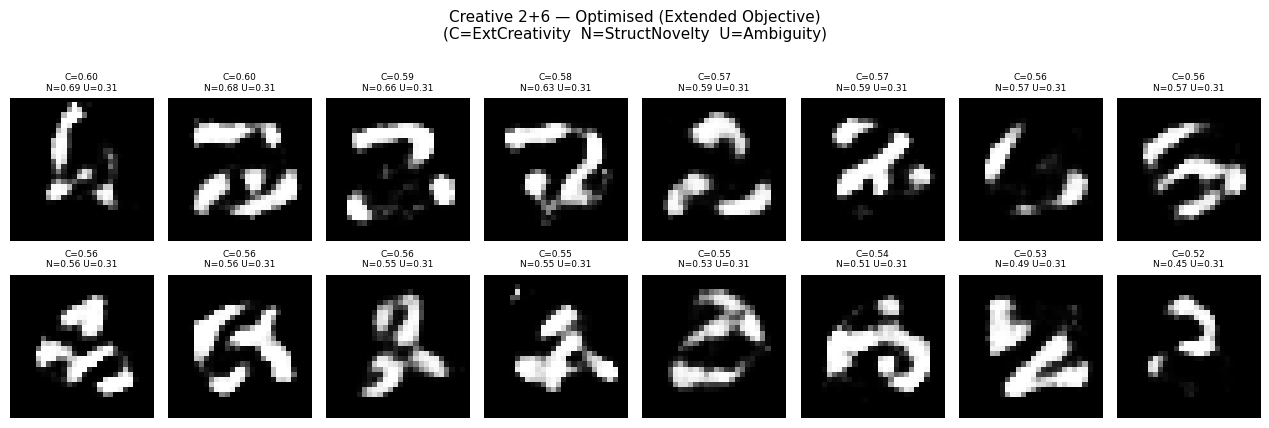

  Saved -> images/creative_ext_optimised.png


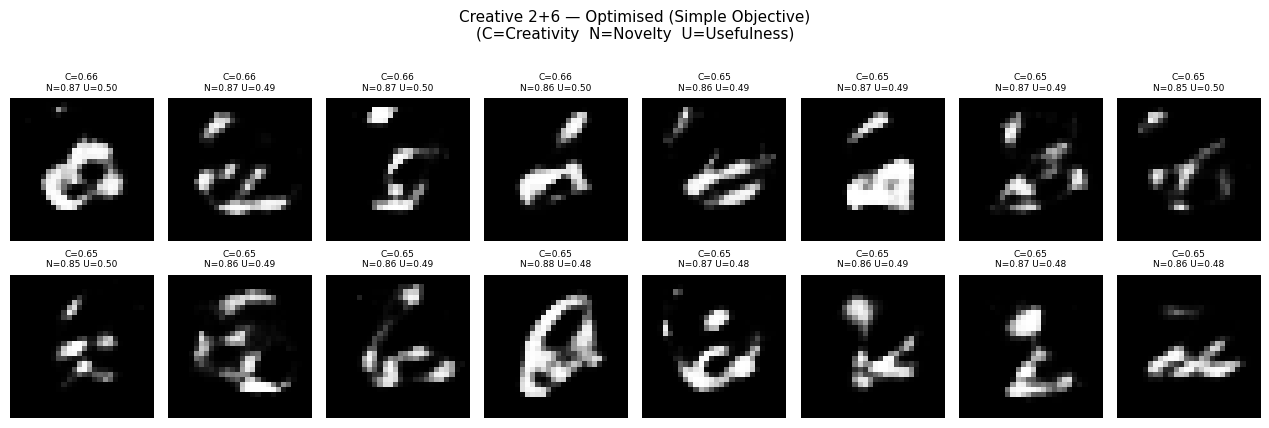

  Saved -> images/creative_simple_optimised.png


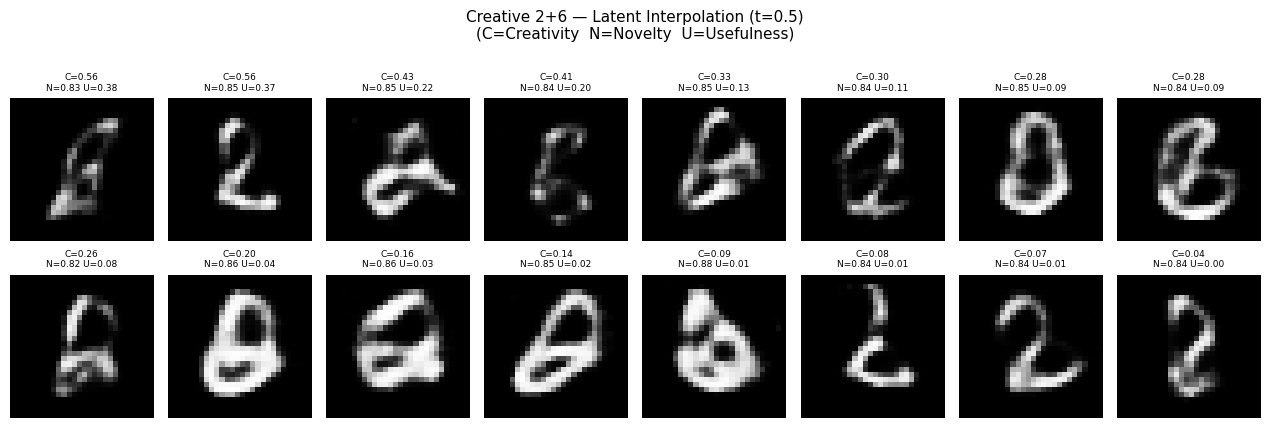

  Saved -> images/creative_interpolated.png


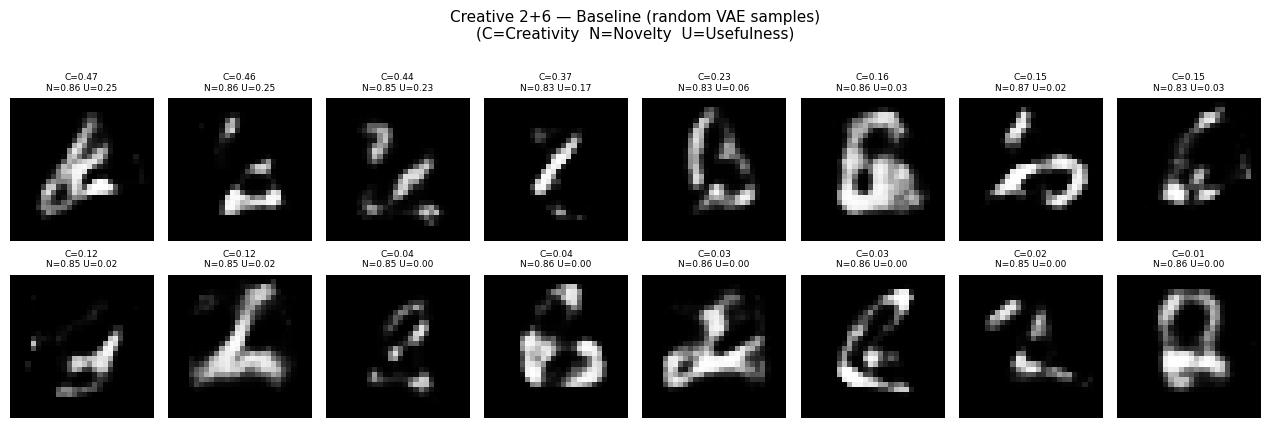

  Saved -> images/creative_baseline.png

[11] Saving comparison plot ...


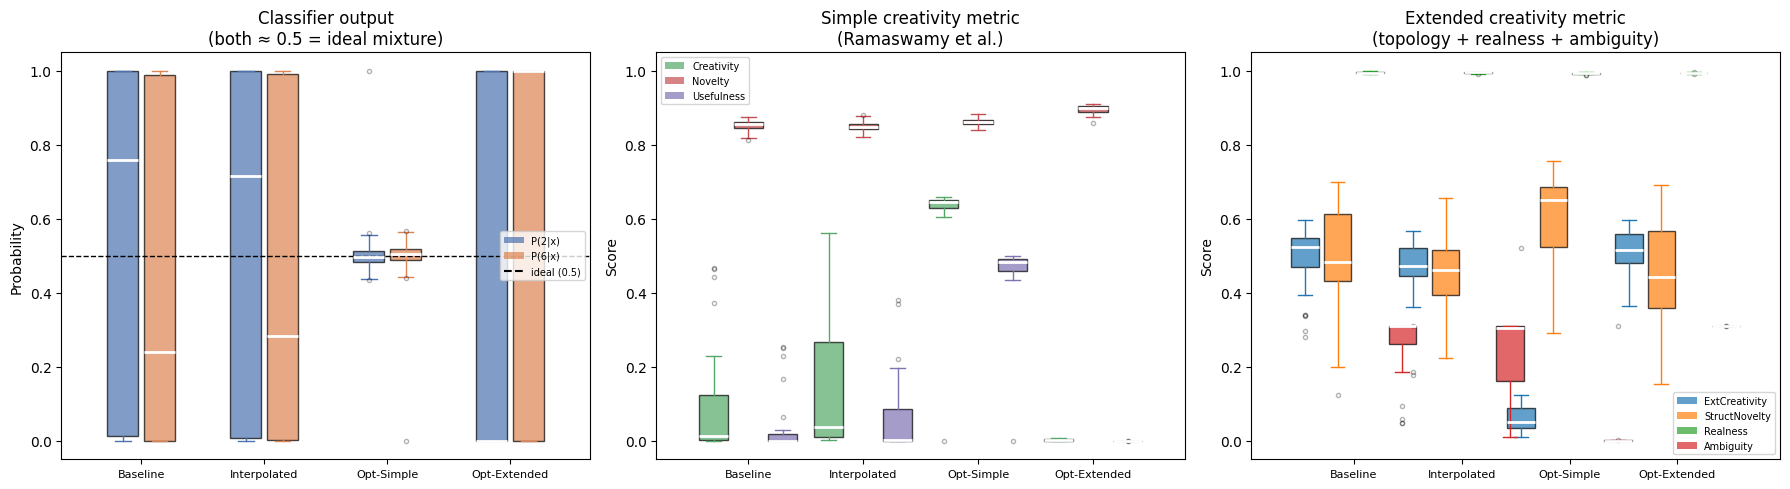

  Saved -> images/comparison_extended.png

Done.


In [13]:
# ─────────────────────────────────────────────────────────────
# 9. Main
# ─────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

# ── Data ──────────────────────────────────────────────────
print("[1] Loading MNIST digits 2 & 6 ...")
train_loader = get_mnist_26(batch_size=128, train=True)
train_flat   = cache_flat_images(train_loader)
print(f"    {len(train_flat)} training images cached.\n")

# ── VAE ───────────────────────────────────────────────────
print("[2] Training VAE ...")
vae = VAE(latent_dim=32).to(device)
train_vae(vae, train_loader, epochs=100, lr=1e-3, device=device, beta=1.0)

# ── Classifier ────────────────────────────────────────────
print("\n[3] Training 2-vs-6 classifier ...")
clf = Classifier().to(device)
train_classifier(clf, train_loader, epochs=10, lr=1e-3, device=device)

# ── General AE (all MNIST, for realness scoring) ──────────
print("\n[4] Training general MNIST autoencoder ...")
ae = GeneralAE(latent_dim=64).to(device)
train_general_ae(ae, epochs=100, lr=1e-3, device=device)

# ── Training persistence diagrams (for topo novelty) ──────
print("\n[5] Computing training H1 persistence diagrams ...")
if TOPO_AVAILABLE:
    train_diagrams = compute_train_diagrams(train_flat, n_samples=150, seed=0)
    print(f"    {len(train_diagrams)} diagrams ready.")
else:
    train_diagrams = []
    print("    Skipped (gudhi not available).")

# ── Shared pixel-space training subset (for nn speed) ─────
rng      = np.random.default_rng(0)
sub      = rng.choice(len(train_flat), size=min(2000, len(train_flat)), replace=False)
train_sub = train_flat[sub]

# ── Generate samples ──────────────────────────────────────
print("\n[6] Generating samples ...")

with torch.no_grad():
    baseline = vae.sample(32, device).cpu()

interp = generate_interpolated(vae, train_loader, n_samples=32,
                                t=0.5, device=device)

print("  Optimising with simple creativity objective ...")
creative_simple = generate_creative(
    vae, clf, train_sub,
    n_samples=32, n_steps=3000, lr=0.05, device=device, alpha=0.2
)

print("  Optimising with extended creativity objective ...")
creative_ext = generate_creative_extended(
    vae, clf, ae, train_sub,
    n_samples=32, n_steps=3000, lr=0.05, device=device, weights=(1/3, 1/3, 1/3)
)

# ── Simple creativity scores ──────────────────────────────
print("\n[7] Scoring — simple metric ...")
bc, bn, bu = score_creativity(baseline,       clf, train_sub, device=device)
ic, in_, iu = score_creativity(interp,        clf, train_sub, device=device)
cc, cn, cu  = score_creativity(creative_simple, clf, train_sub, device=device)
ec, en, eu  = score_creativity(creative_ext,  clf, train_sub, device=device)

# ── Extended creativity scores ────────────────────────────
print("[8] Scoring — extended metric ...")
bec, bsn, br, ba = score_creativity_extended(
    baseline,       clf, ae, train_sub, train_diagrams, device=device)
iec, isn, ir, ia = score_creativity_extended(
    interp,         clf, ae, train_sub, train_diagrams, device=device)
cec, csn, cr, ca = score_creativity_extended(
    creative_simple, clf, ae, train_sub, train_diagrams, device=device)
eec, esn, er, ea = score_creativity_extended(
    creative_ext,   clf, ae, train_sub, train_diagrams, device=device)

# ── Summary tables ────────────────────────────────────────
print("\n[9] Summary — simple metric")
hdr = f"    {'Method':<18} {'Creativity':>10} {'Novelty':>10} {'Usefulness':>12}"
print(hdr); print(f"    {'─'*52}")
for name, c, n_, u in [("Baseline",        bc, bn, bu),
                        ("Interpolated",    ic, in_, iu),
                        ("Opt-Simple",      cc, cn, cu),
                        ("Opt-Extended",    ec, en, eu)]:
    print(f"    {name:<18} {c.mean():>10.4f} {n_.mean():>10.4f} {u.mean():>12.4f}")

print("\n[9] Summary — extended metric")
hdr2 = f"    {'Method':<18} {'ExtCreat':>10} {'StructNov':>11} {'Realness':>10} {'Ambiguity':>11}"
print(hdr2); print(f"    {'─'*64}")
for name, ec_, sn, r, a in [("Baseline",     bec, bsn, br, ba),
                              ("Interpolated", iec, isn, ir, ia),
                              ("Opt-Simple",   cec, csn, cr, ca),
                              ("Opt-Extended", eec, esn, er, ea)]:
    print(f"    {name:<18} {ec_.mean():>10.4f} {sn.mean():>11.4f} "
          f"{r.mean():>10.4f} {a.mean():>11.4f}")

# ── Classifier probability helper ────────────────────────
bp  = get_probs(baseline,        clf, device=device)
ip  = get_probs(interp,          clf, device=device)
cp  = get_probs(creative_simple, clf, device=device)
ep  = get_probs(creative_ext,    clf, device=device)

# ── Image grids ───────────────────────────────────────────
print("\n[10] Saving image grids ...")
visualize(creative_ext, eec, esn, ea,
          title="Creative 2+6 — Optimised (Extended Objective)\n"
                "(C=ExtCreativity  N=StructNovelty  U=Ambiguity)",
          filename="images/creative_ext_optimised.png")
visualize(creative_simple, cc, cn, cu,
          title="Creative 2+6 — Optimised (Simple Objective)\n"
                "(C=Creativity  N=Novelty  U=Usefulness)",
          filename="images/creative_simple_optimised.png")
visualize(interp, ic, in_, iu,
          title="Creative 2+6 — Latent Interpolation (t=0.5)\n"
                "(C=Creativity  N=Novelty  U=Usefulness)",
          filename="images/creative_interpolated.png")
visualize(baseline, bc, bn, bu,
          title="Creative 2+6 — Baseline (random VAE samples)\n"
                "(C=Creativity  N=Novelty  U=Usefulness)",
          filename="images/creative_baseline.png")

# ── Comparison plot ───────────────────────────────────────
print("\n[11] Saving comparison plot ...")
plot_comparison_extended(
    probs_dict={
        "Baseline":     bp,
        "Interpolated": ip,
        "Opt-Simple":   cp,
        "Opt-Extended": ep,
    },
    simple_dict={
        "Baseline":     (bc, bn, bu),
        "Interpolated": (ic, in_, iu),
        "Opt-Simple":   (cc, cn, cu),
        "Opt-Extended": (ec, en, eu),
    },
    extended_dict={
        "Baseline":     (bec, bsn, br, ba),
        "Interpolated": (iec, isn, ir, ia),
        "Opt-Simple":   (cec, csn, cr, ca),
        "Opt-Extended": (eec, esn, er, ea),
    },
    filename="images/comparison_extended.png"
)
print("\nDone.")

[10] REINFORCE latent-space search (warm-started) ...
  [RL ] warm-start: mu init from midpoint of 32 class-2 and 32 class-6 encodings (||mu||=1.336)
  [RL ] ep   50/1000  reward=0.0501  novelty=0.8480  usefulness=0.0373  realism=0.8599  sigma=1.000
  [RL ] ep  100/1000  reward=0.0269  novelty=0.8468  usefulness=0.0193  realism=0.8614  sigma=1.000
  [RL ] ep  150/1000  reward=0.0510  novelty=0.8449  usefulness=0.0374  realism=0.8620  sigma=0.999
  [RL ] ep  200/1000  reward=0.0632  novelty=0.8473  usefulness=0.0455  realism=0.8566  sigma=0.999
  [RL ] ep  250/1000  reward=0.0622  novelty=0.8471  usefulness=0.0452  realism=0.8553  sigma=0.999
  [RL ] ep  300/1000  reward=0.0617  novelty=0.8463  usefulness=0.0445  realism=0.8624  sigma=0.998
  [RL ] ep  350/1000  reward=0.0465  novelty=0.8474  usefulness=0.0314  realism=0.8549  sigma=0.998
  [RL ] ep  400/1000  reward=0.0530  novelty=0.8453  usefulness=0.0384  realism=0.8593  sigma=0.998
  [RL ] ep  450/1000  reward=0.0669  novelty=0.847

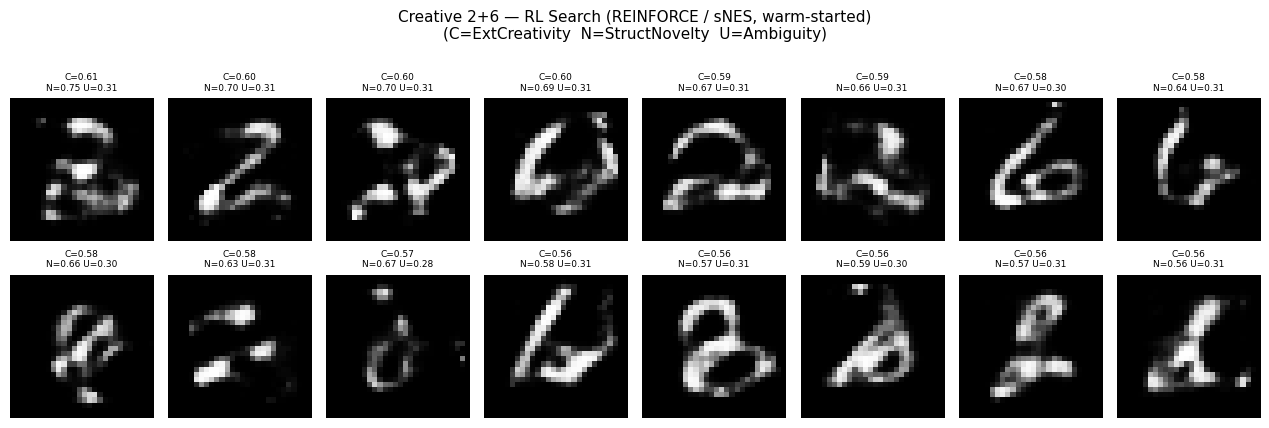

  Saved -> images/creative_rl.png


In [14]:
# ─────────────────────────────────────────────────────────────
# 10. RL search (REINFORCE / sNES) — warm-started, larger population
# ─────────────────────────────────────────────────────────────
# Warm-start: policy mean initialised from the midpoint of averaged
#             class-2 and class-6 encodings (informed prior).
# Bumped: n_samples 32 -> 128  (4x lower gradient variance)
#         n_episodes 200 -> 500 (more time to converge)
# Total decoder evaluations: 128 * 500 = 64,000  (~10x the cold-start run)
print("[10] REINFORCE latent-space search (warm-started) ...")
creative_rl, rl_hist = generate_creative_rl(
    vae, clf, train_sub,
    n_samples=128, n_episodes=1000,
    lr_mu=0.05, lr_sigma=0.01, init_sigma=1.0,
    alpha=0.2,
    baseline_decay=0.9,
    device=device,
    warm_start_loader=train_loader,
    warm_start_pairs=32,
)

# The warm-started policy yields 128 final images; subsample to 32 for
# visualisation and apples-to-apples comparison with the other methods.
_perm = np.random.default_rng(0).permutation(creative_rl.size(0))[:32]
creative_rl = creative_rl[_perm]

# ── Score ─────────────────────────────────────────────────
rl_c, rl_n, rl_u = score_creativity(
    creative_rl, clf, train_sub, device=device, alpha=0.2)
rl_ec, rl_sn, rl_r, rl_a = score_creativity_extended(
    creative_rl, clf, ae, train_sub, train_diagrams, device=device)

print(f"\n  RL simple:   creativity={rl_c.mean():.4f}  "
      f"novelty={rl_n.mean():.4f}  usefulness={rl_u.mean():.4f}")
print(f"  RL extended: ext={rl_ec.mean():.4f}  "
      f"struct_nov={rl_sn.mean():.4f}  "
      f"realness={rl_r.mean():.4f}  ambiguity={rl_a.mean():.4f}")

rl_p = get_probs(creative_rl, clf, device=device)

# ── Visualise ─────────────────────────────────────────────
visualize(creative_rl, rl_ec, rl_sn, rl_a,
          title="Creative 2+6 — RL Search (REINFORCE / sNES, warm-started)\n"
                "(C=ExtCreativity  N=StructNovelty  U=Ambiguity)",
          filename="images/creative_rl.png")


[11] Tracking GD convergence (re-run for history) ...
  Done. Plotting ...


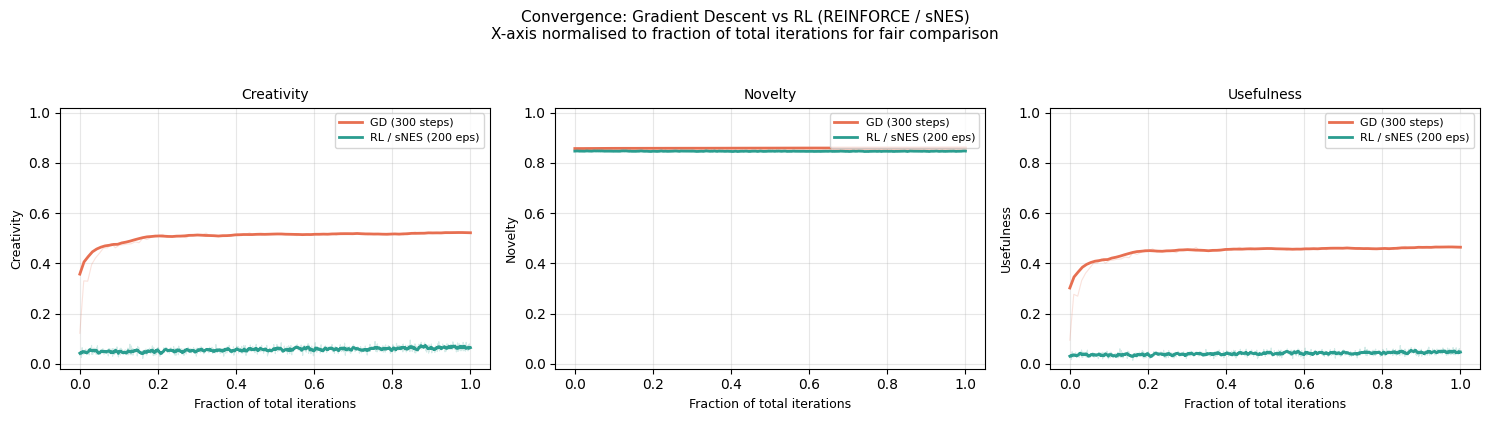

  Saved -> convergence_gd_vs_rl.png


In [15]:
# ─────────────────────────────────────────────────────────────
# 11. Convergence comparison: Gradient Descent vs RL
# ─────────────────────────────────────────────────────────────
# Re-run GD with per-step exact creativity history so curves
# are comparable to rl_hist.  Same hyperparameters as
# generate_creative: alpha=0.2, lr=0.05, n_steps=300, n_samples=32.
print("[11] Tracking GD convergence (re-run for history) ...")

_gd_hist: dict = {"reward": [], "novelty": [], "usefulness": []}
vae.eval(); clf.eval()

_z      = torch.randn(32, vae.latent_dim, device=device, requires_grad=True)
_opt_gd = optim.Adam([_z], lr=0.05)
_tt     = torch.tensor(train_sub, dtype=torch.float32, device=device)
_nbrs_c = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(train_sub)
_N_G, _al = 32, 0.2

for _s in range(300):
    _opt_gd.zero_grad()
    _im  = vae.decoder(_z)
    _pr  = clf.probs(_im)
    _us  = torch.min(_pr[:, 0], _pr[:, 1])
    _fl  = _im.view(_N_G, -1)
    _nd  = torch.cdist(_fl, _tt).min(dim=1).values
    _nv  = _nd / (1.0 + _nd)
    _cr  = (_nv ** _al) * (_us ** (1.0 - _al))
    (-_cr.mean()).backward()
    _opt_gd.step()
    # Record exact score every 3 steps
    if _s % 3 == 0:
        with torch.no_grad():
            _ic = vae.decoder(_z).cpu()
        _cs, _ns, _us2 = score_creativity(_ic, clf, train_sub,
                                           device=device, alpha=_al)
        _gd_hist["reward"].append(float(_cs.mean()))
        _gd_hist["novelty"].append(float(_ns.mean()))
        _gd_hist["usefulness"].append(float(_us2.mean()))

print("  Done. Plotting ...")

# ── Normalise both to [0, 1] for fair speed comparison ────
# GD: 300 steps recorded every 3 -> 100 points
# RL: 200 episodes -> 200 points
gd_x = np.linspace(0, 1, len(_gd_hist["reward"]))
rl_x = np.linspace(0, 1, len(rl_hist["reward"]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
keys   = ["reward",     "novelty",  "usefulness"]
titles = ["Creativity", "Novelty",  "Usefulness"]
gd_col, rl_col = "#E76F51", "#2A9D8F"


def _smooth(arr, w=7):
    # Simple moving average
    if len(arr) <= w:
        return np.array(arr)
    return np.convolve(arr, np.ones(w) / w, mode="valid")


for ax, key, title in zip(axes, keys, titles):
    gd_sm = _smooth(_gd_hist[key])
    rl_sm = _smooth(rl_hist[key])
    gd_sx = np.linspace(0, 1, len(gd_sm))
    rl_sx = np.linspace(0, 1, len(rl_sm))

    ax.plot(gd_x, _gd_hist[key], color=gd_col, alpha=0.2, linewidth=0.8)
    ax.plot(rl_x, rl_hist[key],  color=rl_col,  alpha=0.2, linewidth=0.8)
    ax.plot(gd_sx, gd_sm, color=gd_col, linewidth=2.0,
            label="GD (300 steps)")
    ax.plot(rl_sx, rl_sm, color=rl_col,  linewidth=2.0,
            label="RL / sNES (200 eps)")

    ax.set_xlabel("Fraction of total iterations", fontsize=9)
    ax.set_ylabel(title, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Convergence: Gradient Descent vs RL (REINFORCE / sNES)\n"
    "X-axis normalised to fraction of total iterations for fair comparison",
    fontsize=11, y=1.04)
plt.tight_layout()
plt.savefig("images/convergence_gd_vs_rl.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved -> convergence_gd_vs_rl.png")


[12] Saving full 5-method comparison plot ...


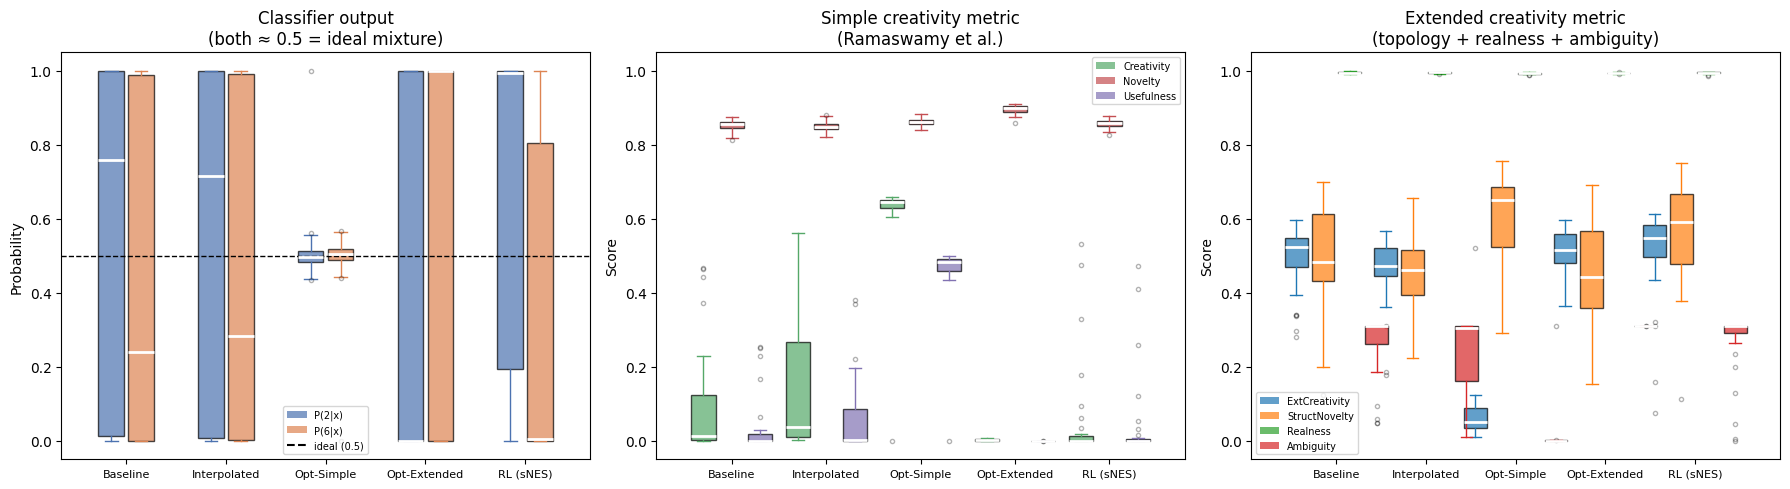

  Saved -> images/comparison_with_rl.png

Full summary — simple creativity metric
    Method             Creativity    Novelty   Usefulness
    ────────────────────────────────────────────────────
    Baseline               0.0902     0.8512       0.0339
    Interpolated           0.1386     0.8493       0.0565
    Opt-Simple             0.6203     0.8614       0.4613
    Opt-Extended           0.0024     0.8956       0.0000
    RL (sNES)              0.0551     0.8576       0.0432

Full summary — extended creativity metric
    Method               ExtCreat   StructNov   Realness   Ambiguity
    ────────────────────────────────────────────────────────────────
    Baseline               0.4939      0.5024     0.9945      0.2659
    Interpolated           0.4563      0.4583     0.9951      0.2403
    Opt-Simple             0.0718      0.6001     0.9935      0.0104
    Opt-Extended           0.5096      0.4485     0.9941      0.3112
    RL (sNES)              0.5063      0.5688     0.9937

In [16]:
# ─────────────────────────────────────────────────────────────
# 12. Full comparison — all 5 methods including RL
# ─────────────────────────────────────────────────────────────
print("[12] Saving full 5-method comparison plot ...")

plot_comparison_extended(
    probs_dict={
        "Baseline":     bp,
        "Interpolated": ip,
        "Opt-Simple":   cp,
        "Opt-Extended": ep,
        "RL (sNES)":    rl_p,
    },
    simple_dict={
        "Baseline":     (bc,   bn,   bu),
        "Interpolated": (ic,   in_,  iu),
        "Opt-Simple":   (cc,   cn,   cu),
        "Opt-Extended": (ec,   en,   eu),
        "RL (sNES)":    (rl_c, rl_n, rl_u),
    },
    extended_dict={
        "Baseline":     (bec,  bsn,  br,    ba),
        "Interpolated": (iec,  isn,  ir,    ia),
        "Opt-Simple":   (cec,  csn,  cr,    ca),
        "Opt-Extended": (eec,  esn,  er,    ea),
        "RL (sNES)":    (rl_ec, rl_sn, rl_r, rl_a),
    },
    filename="images/comparison_with_rl.png",
)

# ── Summary tables ─────────────────────────────────────────
print("\nFull summary — simple creativity metric")
hdr = f"    {'Method':<18} {'Creativity':>10} {'Novelty':>10} {'Usefulness':>12}"
print(hdr); print(f"    {'─' * 52}")
for name, c_, n_, u_ in [
    ("Baseline",      bc,   bn,   bu),
    ("Interpolated",  ic,   in_,  iu),
    ("Opt-Simple",    cc,   cn,   cu),
    ("Opt-Extended",  ec,   en,   eu),
    ("RL (sNES)",     rl_c, rl_n, rl_u),
]:
    print(f"    {name:<18} {c_.mean():>10.4f} {n_.mean():>10.4f} {u_.mean():>12.4f}")

print("\nFull summary — extended creativity metric")
hdr2 = (f"    {'Method':<18} {'ExtCreat':>10} {'StructNov':>11}"
        f" {'Realness':>10} {'Ambiguity':>11}")
print(hdr2); print(f"    {'─' * 64}")
for name, ec_, sn_, r_, a_ in [
    ("Baseline",      bec,   bsn,   br,    ba),
    ("Interpolated",  iec,   isn,   ir,    ia),
    ("Opt-Simple",    cec,   csn,   cr,    ca),
    ("Opt-Extended",  eec,   esn,   er,    ea),
    ("RL (sNES)",     rl_ec, rl_sn, rl_r, rl_a),
]:
    print(f"    {name:<18} {ec_.mean():>10.4f} {sn_.mean():>11.4f}"
          f" {r_.mean():>10.4f} {a_.mean():>11.4f}")

print("\nDone (RL section complete).")


[13a] Training 10-class classifier for Option A ...
  [CLF10] epoch  1/5  loss=0.3538  acc=0.9016
  [CLF10] epoch  2/5  loss=0.1366  acc=0.9589
  [CLF10] epoch  3/5  loss=0.0865  acc=0.9738
  [CLF10] epoch  4/5  loss=0.0620  acc=0.9810
  [CLF10] epoch  5/5  loss=0.0483  acc=0.9852

[13b] Fitting per-class latent Gaussians for Option B ...
  class 2: ||mu||=2.086  cond(prec)=1.01e+02
  class 6: ||mu||=1.866  cond(prec)=1.41e+02

[13c] Option A — 10-class usefulness ...
  [RL-A] ep  100/500  reward=0.1442  u1=0.870  u2=0.159  nov=0.846  sigma=0.999
  [RL-A] ep  200/500  reward=0.1656  u1=0.828  u2=0.178  nov=0.847  sigma=0.998
  [RL-A] ep  300/500  reward=0.1258  u1=0.855  u2=0.149  nov=0.845  sigma=0.996
  [RL-A] ep  400/500  reward=0.1674  u1=0.887  u2=0.169  nov=0.846  sigma=0.994
  [RL-A] ep  500/500  reward=0.1735  u1=0.844  u2=0.204  nov=0.848  sigma=0.991

[13d] Option B — Mahalanobis novelty ...
  [RL-B] ep  100/500  reward=0.0500  real=0.864  use=0.036  nov=0.904  sigma=1.000
  

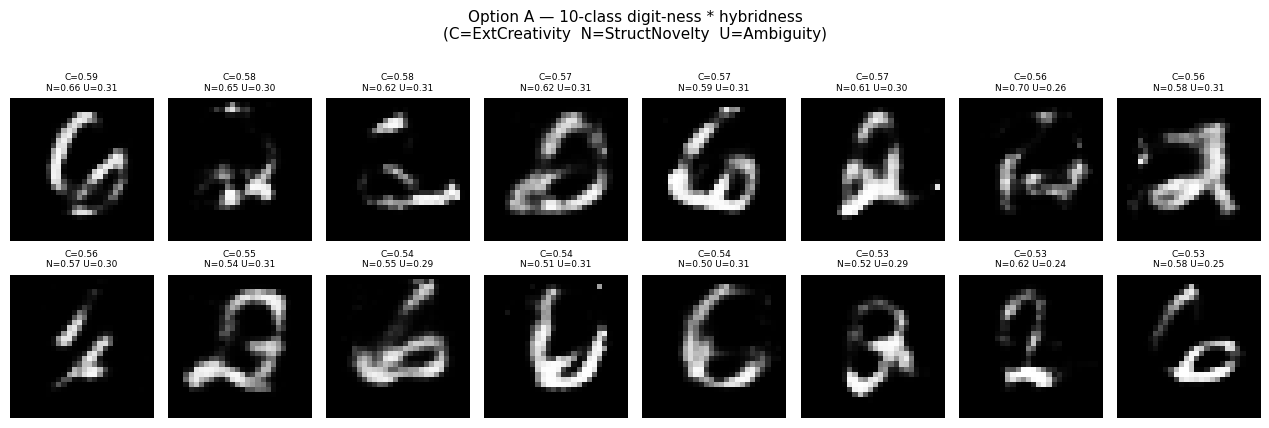

  Saved -> images/creative_rl_option_A.png


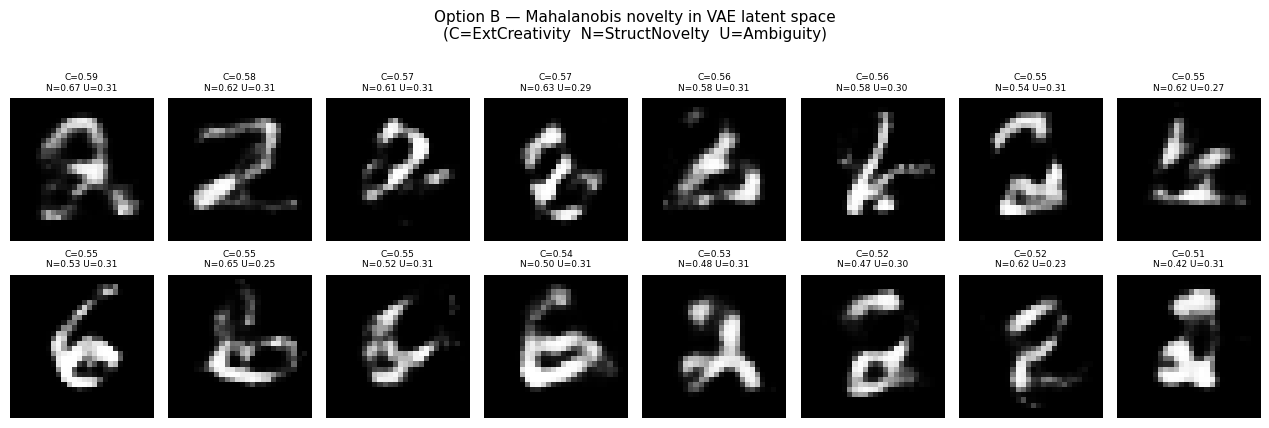

  Saved -> images/creative_rl_option_B.png
    Saved: creative_rl_option_A.png, creative_rl_option_B.png, creative_rl_A_vs_B.png


In [17]:
# ─────────────────────────────────────────────────────────────
# 13. Creativity metric ablation: Option A vs Option B
# ─────────────────────────────────────────────────────────────
#
# Both variants share a single RL loop (REINFORCE / sNES with KL trust
# region to N(0, I)) and differ only in the reward function:
#
#   A: 10-class classifier usefulness
#       usefulness(z) = (p_2 + p_6) * (1 - |p_2 - p_6| / (p_2 + p_6))
#       novelty(z)    = latent-space 1-NN distance (as before)
#      Rationale: forces the classifier to first recognise the decode
#      as a digit, and only *among that mass* rewards ambiguity between
#      2 and 6.  Blurry midpoints of the 2-class classifier -- which
#      trivially scored 0.5/0.5 before -- now get low p_2 + p_6 because
#      the 10-class model says "probably a 3 or 8".
#
#   B: per-class Mahalanobis novelty in latent space
#       Fit a Gaussian to the encoded training 2s and to the encoded
#       training 6s: (mu_k, Sigma_k) for k in {2, 6}.
#       novelty(z) = min_k sqrt( (z - mu_k)^T Sigma_k^{-1} (z - mu_k) )
#                    bounded via d / (1 + d)
#      Rationale: unlike 1-NN, this is a *density*-based novelty.  It
#      penalises moving into the void between clusters *and* penalises
#      any direction (scaled by the covariance) rather than rewarding
#      distance from individual points only.  Off-manifold garbage is
#      "novel" under both formulations, but B respects the geometry of
#      the training distribution rather than its pointwise support.
#      The usefulness term is the original min(p_2, p_6) * cycle-realism
#      so that changes are attributable to novelty, not usefulness.

from copy import deepcopy


# ── 13a. 10-class classifier (Option A) ─────────────────────
class Classifier10(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

    def probs(self, x):
        return F.softmax(self.forward(x), dim=1)


def get_mnist_all(batch_size: int = 128, train: bool = True):
    dataset = torchvision.datasets.MNIST(
        root="./data", train=train, download=True,
        transform=transforms.ToTensor()
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=train)


def train_classifier_10(clf, loader, epochs=5, lr=1e-3, device="cpu"):
    opt = optim.Adam(clf.parameters(), lr=lr)
    clf.train()
    for epoch in range(epochs):
        total, correct, n = 0.0, 0, 0
        for x, y in loader:
            x = x.to(device); y = y.to(device)
            logits = clf(x)
            loss = F.cross_entropy(logits, y)
            opt.zero_grad(); loss.backward(); opt.step()
            total   += loss.item()
            correct += (logits.argmax(1) == y).sum().item()
            n       += y.size(0)
        print(f"  [CLF10] epoch {epoch+1:>2}/{epochs}  "
              f"loss={total/len(loader):.4f}  acc={correct/n:.4f}")


# ── 13b. Fit per-class latent Gaussians (Option B) ──────────
def fit_class_gaussians(vae, loader, device, n_per_class=512, reg=1e-3):
    """Return {2: (mu, precision), 6: (mu, precision)} in VAE latent space."""
    vae.eval()
    buckets = {2: [], 6: []}
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            m, _ = vae.encode(x)
            for cls in (2, 6):
                mask = (y == cls)
                if mask.any():
                    buckets[cls].append(m[mask].cpu().numpy())
            if all(sum(a.shape[0] for a in buckets[c]) >= n_per_class
                   for c in (2, 6)):
                break
    stats = {}
    for cls, parts in buckets.items():
        Z  = np.concatenate(parts, axis=0)[:n_per_class].astype(np.float64)
        mu = Z.mean(axis=0)
        Zc = Z - mu
        Sigma = (Zc.T @ Zc) / (len(Z) - 1) + reg * np.eye(Z.shape[1])
        stats[cls] = (mu, np.linalg.inv(Sigma))
    return stats


# ── 13c. Shared RL loop parameterised by a reward function ──
def generate_creative_rl_variant(
    vae, reward_fn, *,
    n_samples=128, n_episodes=500,
    lr_mu=0.05, lr_sigma=0.01, init_sigma=1.0,
    baseline_decay=0.9, kl_beta=0.05,
    device="cpu",
    warm_start_loader=None, warm_start_pairs=32,
    label="RL",
):
    vae.eval()
    d = vae.latent_dim

    if warm_start_loader is not None:
        mu = _warm_start_mu(vae, warm_start_loader, device, warm_start_pairs)
    else:
        mu = np.zeros(d, dtype=np.float64)

    log_sig  = np.full(d, np.log(init_sigma), dtype=np.float64)
    baseline = 0.0
    hist     = {"reward": [], "sigma": []}

    for ep in range(n_episodes):
        sigma = np.exp(log_sig)
        eps   = np.random.randn(n_samples, d)
        z_np  = (mu[None] + sigma[None] * eps).astype(np.float32)

        with torch.no_grad():
            imgs = vae.decoder(torch.tensor(z_np, device=device)).cpu()

        rewards, info = reward_fn(z_np, imgs)

        adv      = rewards - baseline
        baseline = (baseline_decay * baseline
                    + (1 - baseline_decay) * float(rewards.mean()))

        adv_col      = adv[:, None]
        grad_mu      = (adv_col * (eps / sigma[None])).mean(axis=0)
        grad_log_sig = (adv_col * (eps ** 2 - 1.0)).mean(axis=0)

        # KL trust region w.r.t. VAE prior N(0, I).
        mu      += lr_mu    * (grad_mu      - kl_beta * mu)
        log_sig += lr_sigma * (grad_log_sig - kl_beta * (sigma ** 2 - 1.0))

        hist["reward"].append(float(rewards.mean()))
        hist["sigma"].append(float(sigma.mean()))
        for k, v in info.items():
            hist.setdefault(k, []).append(float(np.mean(v)))

        if (ep + 1) % 100 == 0:
            extras = "  ".join(f"{k}={np.mean(v):.3f}" for k, v in info.items())
            print(f"  [{label}] ep {ep+1:>4}/{n_episodes}  "
                  f"reward={rewards.mean():.4f}  {extras}  "
                  f"sigma={sigma.mean():.3f}")

    sigma  = np.exp(log_sig)
    z_fin  = (mu[None] + sigma[None]
              * np.random.randn(n_samples, d)).astype(np.float32)
    with torch.no_grad():
        imgs_final = vae.decoder(torch.tensor(z_fin, device=device)).cpu()
    return imgs_final, hist


# ── 13d. Reward function factories ──────────────────────────
def make_reward_A(clf10, nbrs, device, alpha=0.2, eps=1e-6):
    """Option A: 10-class digit-ness * hybridness; 1-NN latent novelty."""
    def reward_fn(z_np, imgs):
        with torch.no_grad():
            probs = clf10.probs(imgs.to(device)).cpu().numpy()   # (N, 10)
        p2, p6 = probs[:, 2], probs[:, 6]
        u1     = p2 + p6                                          # digit-ness
        u2     = 1.0 - np.abs(p2 - p6) / (p2 + p6 + eps)          # hybridness
        usefulness = u1 * u2

        nn_dist = nbrs.kneighbors(z_np)[0][:, 0]
        novelty = nn_dist / (1.0 + nn_dist)

        rewards = (novelty ** alpha) * (usefulness ** (1 - alpha))
        return rewards, {"u1": u1, "u2": u2, "nov": novelty}
    return reward_fn


def make_reward_B(vae, clf, class_stats, device, alpha=0.2):
    """Option B: per-class Mahalanobis novelty; original usefulness + realism gate."""
    stats_items = list(class_stats.values())

    def reward_fn(z_np, imgs):
        d = z_np.shape[1]
        with torch.no_grad():
            probs    = clf.probs(imgs.to(device)).cpu().numpy()
            z_hat_np = vae.encode(imgs.to(device))[0].cpu().numpy()

        cyc_err = ((z_np - z_hat_np) ** 2).sum(axis=1) / d
        realism = np.exp(-0.5 * cyc_err)
        usefulness = np.minimum(probs[:, 0], probs[:, 1]) * realism

        dists = []
        z64 = z_np.astype(np.float64)
        for mu_k, prec_k in stats_items:
            delta = z64 - mu_k
            dm2   = np.einsum("ni,ij,nj->n", delta, prec_k, delta)
            dists.append(np.sqrt(np.maximum(dm2, 0.0)))
        dm = np.minimum.reduce(dists)
        novelty = dm / (1.0 + dm)

        rewards = (novelty ** alpha) * (usefulness ** (1 - alpha))
        return rewards, {"real": realism, "use": usefulness, "nov": novelty}
    return reward_fn


# ── 13e. Train 10-class classifier + fit latent Gaussians ───
print("[13a] Training 10-class classifier for Option A ...")
all_loader = get_mnist_all(batch_size=128, train=True)
clf10 = Classifier10().to(device)
train_classifier_10(clf10, all_loader, epochs=5, lr=1e-3, device=device)

print("\n[13b] Fitting per-class latent Gaussians for Option B ...")
class_stats = fit_class_gaussians(vae, train_loader, device, n_per_class=512)
for cls, (mu_k, prec_k) in class_stats.items():
    print(f"  class {cls}: ||mu||={np.linalg.norm(mu_k):.3f}  "
          f"cond(prec)={np.linalg.cond(prec_k):.2e}")

# Pre-build latent-space NN index for Option A (reuse what 5ff709f7 builds).
with torch.no_grad():
    _train_t      = torch.tensor(train_sub, dtype=torch.float32, device=device)
    _train_latent = vae.encode(_train_t)[0].cpu().numpy()
nbrs_latent = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(_train_latent)


# ── 13f. Run both variants with matched hyper-parameters ────
RL_KW = dict(
    n_samples=128, n_episodes=500,
    lr_mu=0.05, lr_sigma=0.01, init_sigma=1.0,
    baseline_decay=0.9, kl_beta=0.05,
    device=device,
    warm_start_loader=train_loader, warm_start_pairs=32,
)

print("\n[13c] Option A — 10-class usefulness ...")
imgs_A, hist_A = generate_creative_rl_variant(
    vae, make_reward_A(clf10, nbrs_latent, device, alpha=0.2),
    label="RL-A", **RL_KW,
)

print("\n[13d] Option B — Mahalanobis novelty ...")
imgs_B, hist_B = generate_creative_rl_variant(
    vae, make_reward_B(vae, clf, class_stats, device, alpha=0.2),
    label="RL-B", **RL_KW,
)


# ── 13g. Score + visualize ──────────────────────────────────
_perm = np.random.default_rng(0).permutation(imgs_A.size(0))[:32]
imgs_A_vis = imgs_A[_perm]
imgs_B_vis = imgs_B[_perm]

A_ec, A_sn, A_r, A_a = score_creativity_extended(
    imgs_A_vis, clf, ae, train_sub, train_diagrams, device=device)
B_ec, B_sn, B_r, B_a = score_creativity_extended(
    imgs_B_vis, clf, ae, train_sub, train_diagrams, device=device)

print("\n[13e] Extended creativity scores:")
hdr = f"    {'Variant':<30} {'ExtCreat':>10} {'StructNov':>11} {'Realness':>10} {'Ambig':>10}"
print(hdr); print(f"    {'─'*76}")
print(f"    {'A: 10-class usefulness':<30} {A_ec.mean():>10.4f} "
      f"{A_sn.mean():>11.4f} {A_r.mean():>10.4f} {A_a.mean():>10.4f}")
print(f"    {'B: Mahalanobis novelty':<30} {B_ec.mean():>10.4f} "
      f"{B_sn.mean():>11.4f} {B_r.mean():>10.4f} {B_a.mean():>10.4f}")

visualize(imgs_A_vis, A_ec, A_sn, A_a,
          title="Option A — 10-class digit-ness * hybridness\n"
                "(C=ExtCreativity  N=StructNovelty  U=Ambiguity)",
          filename="images/creative_rl_option_A.png")
visualize(imgs_B_vis, B_ec, B_sn, B_a,
          title="Option B — Mahalanobis novelty in VAE latent space\n"
                "(C=ExtCreativity  N=StructNovelty  U=Ambiguity)",
          filename="images/creative_rl_option_B.png")

# Side-by-side panel: A on top, B on bottom.
fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < 32:
        ax.imshow(imgs_A_vis[i, 0].numpy(), cmap="gray"); ax.set_title("A", fontsize=6)
    else:
        ax.imshow(imgs_B_vis[i - 32, 0].numpy(), cmap="gray"); ax.set_title("B", fontsize=6)
    ax.axis("off")
fig.suptitle("Option A (top 4 rows) vs Option B (bottom 4 rows)")
fig.tight_layout()
fig.savefig("images/creative_rl_A_vs_B.png", dpi=150)
plt.close(fig)
print("    Saved: creative_rl_option_A.png, creative_rl_option_B.png, creative_rl_A_vs_B.png")
